In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))
from functions import *

In [2]:
dados = pd.read_csv('../results/data.csv', index_col='Cluster')
df = pd.read_csv('../results/results.csv', index_col ='Cluster')

# Only binaries with q > 0.34

In [3]:
df[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.50,0.41
std,0.13,0.11
min,0.15,0.10
25%,0.41,0.33
50%,0.50,0.40
75%,0.59,0.47
max,0.87,0.85


In [4]:
dados[dados['q']>0][['q','comp_mass']].describe().round(2)

,q,comp_mass
count,63605.00,63605.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


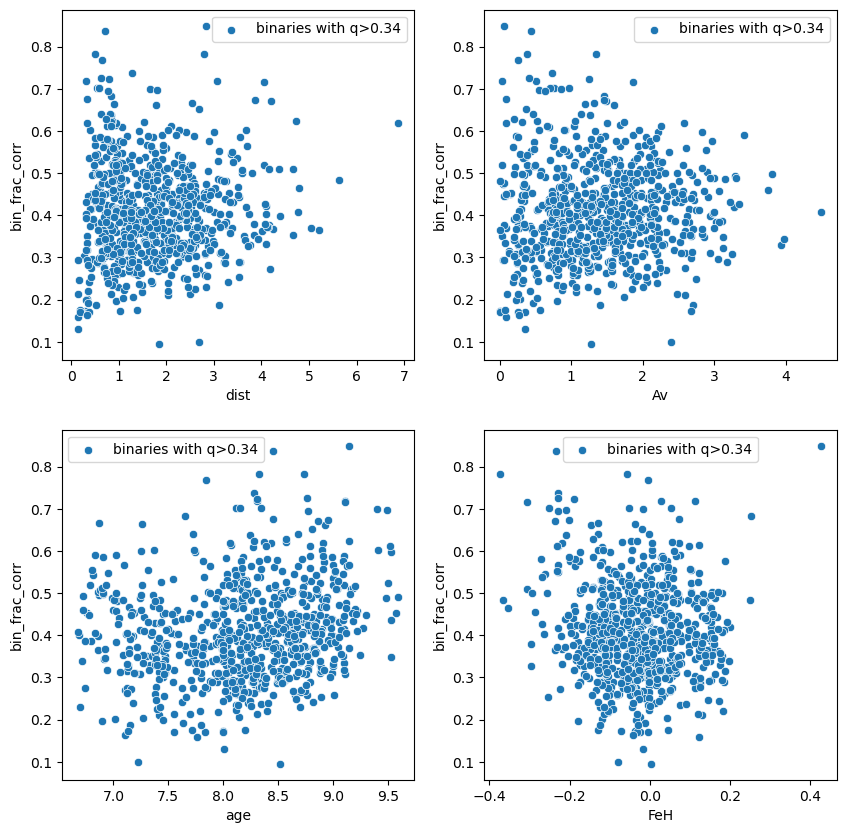

In [5]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='binaries with q>0.34')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

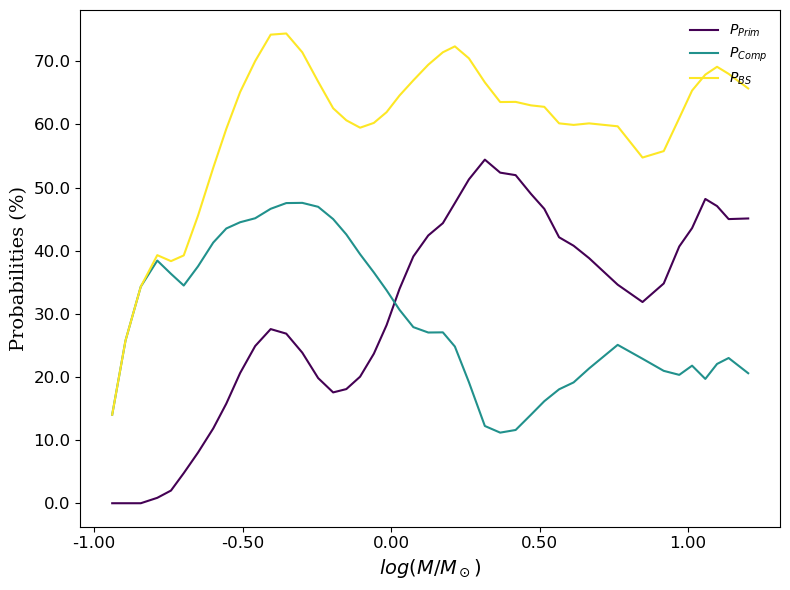

In [6]:
m1 = dados['mass'].values
m2 = dados['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
plt.show()



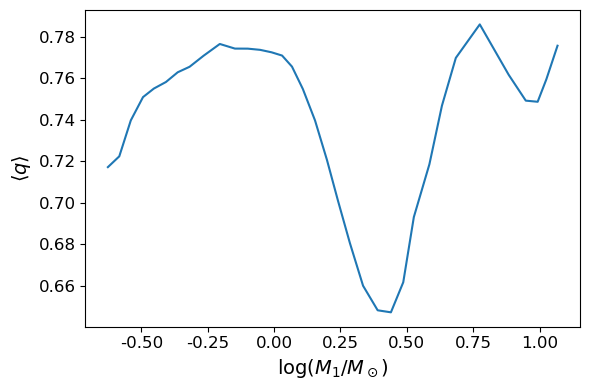

In [7]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show() 



# Only binaries with q>0.5

In [12]:
mask = (dados['q']>0.5) | (dados['q']==0)
aux_2 = dados[mask].copy()

df2 = df.copy()
for cluster in df2.index:
    df2.loc[cluster, 'bin_frac'] = bin_frac(aux_2.loc[cluster])
df2['bin_frac_corr'] = corr_mean(df2,)

In [13]:
df2[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.49,0.39
std,0.13,0.12
min,0.12,0.07
25%,0.40,0.31
50%,0.49,0.37
75%,0.58,0.45
max,0.86,0.84


In [14]:
aux_2[aux_2['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,60183.00,60183.00
mean,0.76,1.05
std,0.13,0.81
min,0.50,0.11
25%,0.64,0.68
50%,0.77,0.91
75%,0.88,1.22
max,0.99,30.43


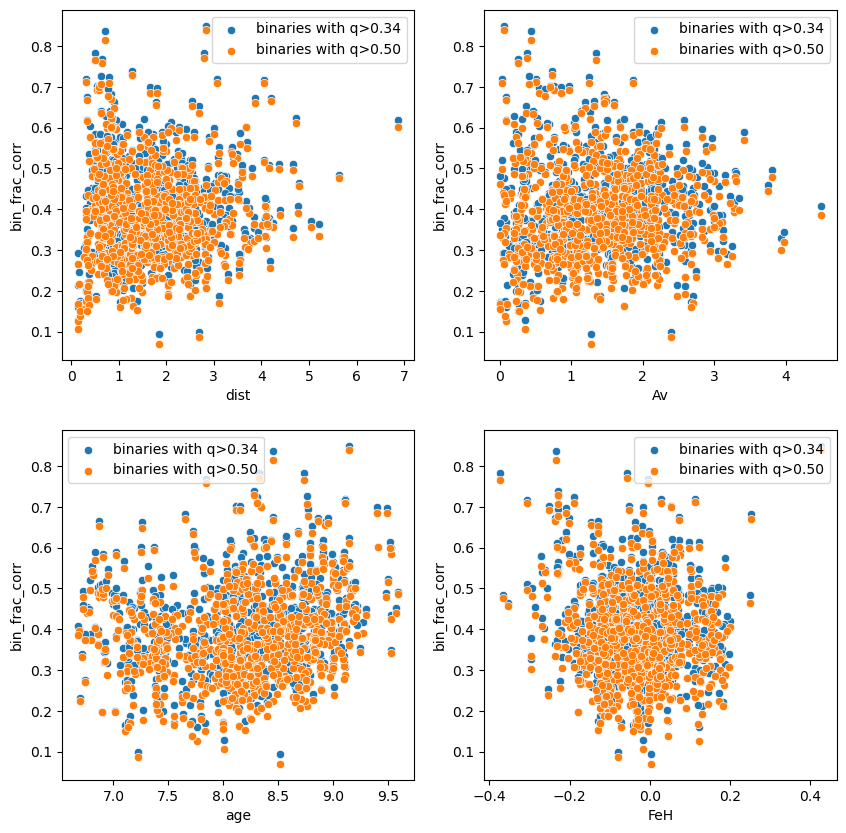

In [15]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='binaries with q>0.34')
    sns.scatterplot(data=df2, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'binaries with q>0.50')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

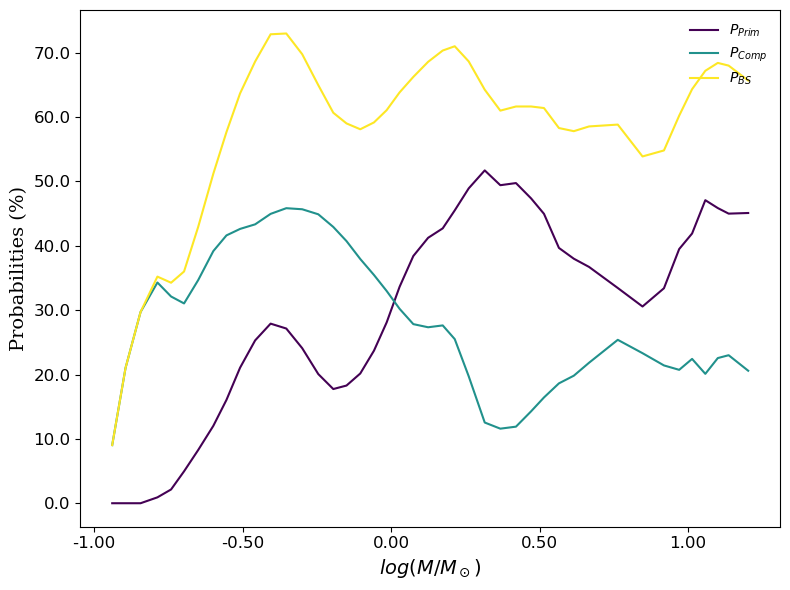

In [16]:
m1 = aux_2['mass'].values
m2 = aux_2['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
plt.show()


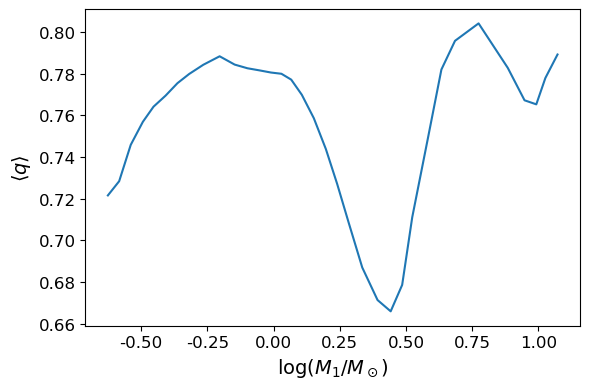

In [17]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show() 


# Only binaries with q>0.6

In [18]:
mask = (dados['q'] > 0.6) | (dados['q'] == 0)
aux_3 = dados[mask].copy()
df3 = df.copy()
for cluster in df3.index:
    df3.loc[cluster, 'bin_frac'] = bin_frac(aux_3.loc[cluster])
df3['bin_frac_corr'] = corr_mean(df3)

In [19]:
df3[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,773.00,773.00
mean,0.44,0.34
std,0.14,0.12
min,0.09,-0.01
25%,0.34,0.26
50%,0.43,0.33
75%,0.54,0.41
max,0.83,0.81


In [20]:
aux_3[aux_3['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,50810.00,50810.00
mean,0.80,1.07
std,0.11,0.85
min,0.60,0.11
25%,0.70,0.70
50%,0.81,0.93
75%,0.89,1.23
max,0.99,30.43


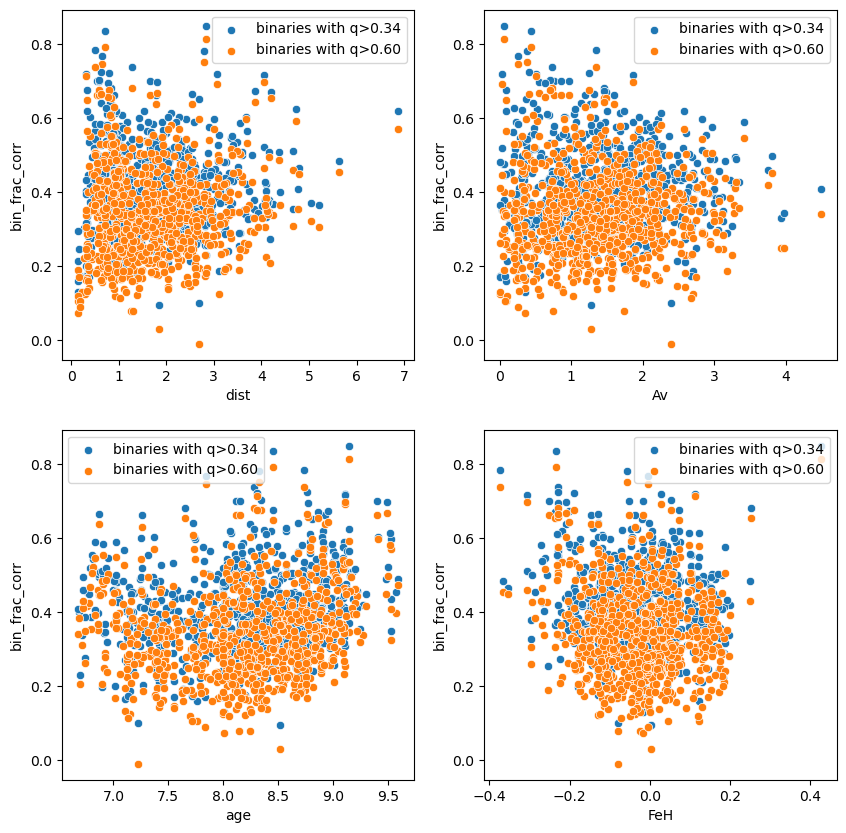

In [21]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='binaries with q>0.34')
    sns.scatterplot(data=df3, x=var, y='bin_frac_corr', ax = axs[i,j], label= 'binaries with q>0.60')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

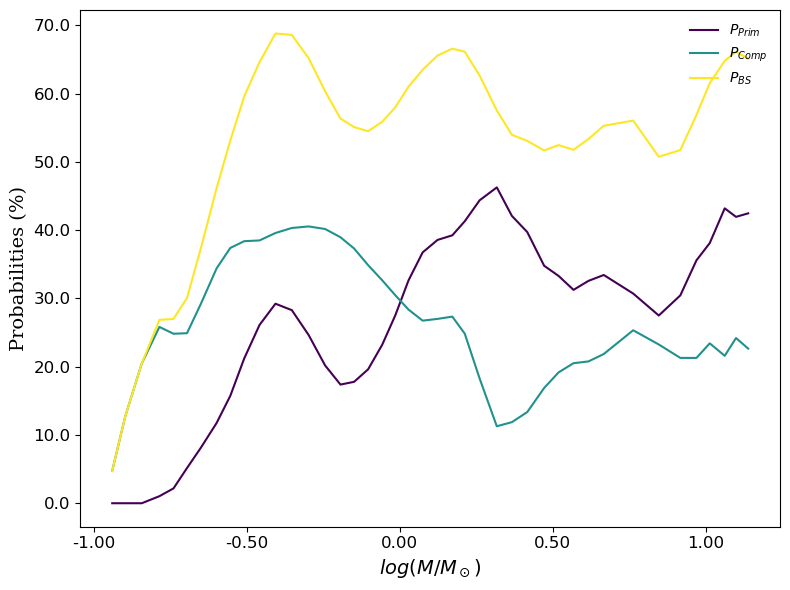

In [22]:
m1 = aux_3['mass'].values
m2 = aux_3['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
plt.show()


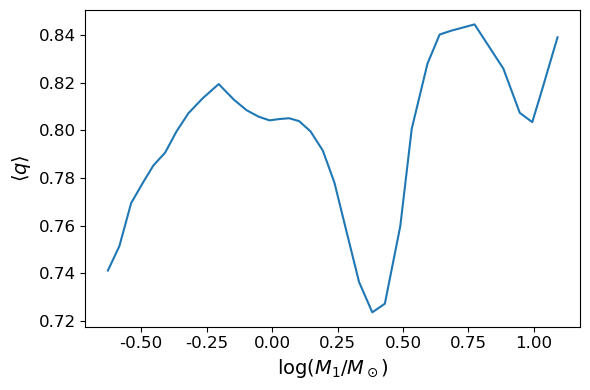

In [23]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show() 


# comparison between the selections

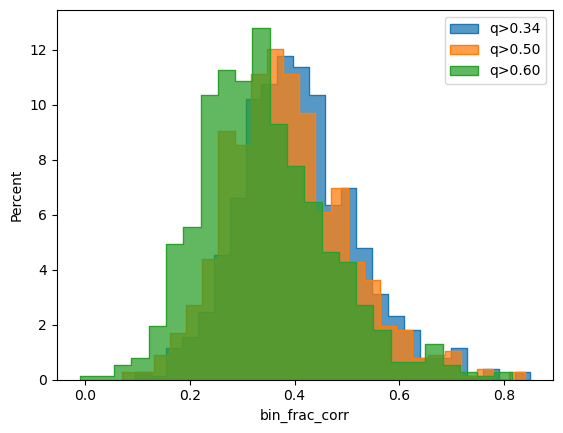

In [24]:
sns.histplot(df['bin_frac_corr'], stat='percent', element='step', label ='q>0.34')
sns.histplot(df2['bin_frac_corr'], stat='percent', element='step', label ='q>0.50')
sns.histplot(df3['bin_frac_corr'], stat='percent', element='step', label ='q>0.60')
plt.legend()
plt.show()